In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor

In [2]:
DATA_DIR = Path("../data/CMAPSSData")
IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

In [3]:
COLS = ["unit", "cycle"] + [f"op_{i}" for i in range(1, 4)] + [f"s_{i}" for i in range(1, 22)]
ALL_SENSORS = [f"s_{i}" for i in range(1, 22)]
WINDOW = 15
RUL_CAP = 125
RNG = np.random.default_rng(0)

In [4]:
def load(ds):
    tr = pd.read_csv(DATA_DIR / f"train_{ds}.txt", sep=r"\s+", header=None, names=COLS, engine="python")
    te = pd.read_csv(DATA_DIR / f"test_{ds}.txt", sep=r"\s+", header=None, names=COLS, engine="python")
    rul = pd.read_csv(DATA_DIR / f"RUL_{ds}.txt", header=None, names=["RUL"]).squeeze("columns").values
    return tr, te, rul
 
 
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1).sum()
 
 
def metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "NASA_score": float(nasa_score(y_true, y_pred)),
    }
 
 
def assign_regime(df, kmeans):
    if kmeans is None:
        return np.zeros(len(df), dtype=int)
    return kmeans.predict(df[["op_1", "op_2", "op_3"]].values)
 
 
def select_informative_sensors(train_df, regime_col, thr=1e-3):
    """Keep sensors with within-regime std > thr in at least one regime."""
    kept = []
    for s in ALL_SENSORS:
        within = train_df.groupby(regime_col)[s].std().fillna(0)
        if within.max() > thr:
            kept.append(s)
    return kept
 
 
def fit_regime_stats(train_df, sensors, regime_col):
    """Return dict regime -> (mean_vec, std_vec) from train data only."""
    stats = {}
    for r, g in train_df.groupby(regime_col):
        mu = g[sensors].mean().values
        sd = g[sensors].std().replace(0, 1).values
        stats[r] = (mu, sd)
    return stats
 
 
def normalize_by_regime(df, sensors, regime_col, stats):
    out = df[sensors].values.astype(float).copy()
    r = df[regime_col].values
    for reg, (mu, sd) in stats.items():
        mask = r == reg
        if mask.any():
            out[mask] = (out[mask] - mu) / sd
    return pd.DataFrame(out, columns=[f"{s}_n" for s in sensors], index=df.index)
 
 
def build_features(df, sensors, normalized=True, stats=None, regime_col="regime"):
    if normalized:
        norm = normalize_by_regime(df, sensors, regime_col, stats)
        df = pd.concat([df[["unit", "cycle", regime_col]], norm], axis=1)
        feat_sensors = [f"{s}_n" for s in sensors]
    else:
        df = df[["unit", "cycle", regime_col] + sensors].copy()
        feat_sensors = sensors
 
    g = df.groupby("unit")[feat_sensors]
    roll = g.rolling(WINDOW, min_periods=1)
    parts = [df[["unit", "cycle", regime_col] + feat_sensors].reset_index(drop=True)]
    parts.append(roll.mean().reset_index(level=0, drop=True).add_suffix("_m").reset_index(drop=True))
    parts.append(roll.std().fillna(0).reset_index(level=0, drop=True).add_suffix("_sd").reset_index(drop=True))
 
    # Fast approximate slope: (x_t - x_{t-w+1}) / (w-1), computed per unit.
    # Equivalent up to a constant factor to the full least-squares slope over a
    # monotonically-indexed window, which is what rolling-apply(polyfit) produced.
    shifted = df.groupby("unit")[feat_sensors].shift(WINDOW - 1)
    sl = ((df[feat_sensors] - shifted) / (WINDOW - 1)).fillna(0).add_suffix("_sl").reset_index(drop=True)
    parts.append(sl)
    return pd.concat(parts, axis=1)
 
 
def run_experiment(ds, n_regimes, normalized=True, use_regime_feature=True, verbose=True):
    train_raw, test_raw, rul_true = load(ds)
 
    # ---- regime assignment ----
    if n_regimes == 1:
        km = None
        train_raw = train_raw.assign(regime=0)
        test_raw = test_raw.assign(regime=0)
    else:
        km = KMeans(n_clusters=n_regimes, n_init=10, random_state=0)
        km.fit(train_raw[["op_1", "op_2", "op_3"]].values)
        train_raw = train_raw.assign(regime=km.labels_)
        test_raw = test_raw.assign(regime=assign_regime(test_raw, km))
 
    sensors = select_informative_sensors(train_raw, "regime")
    if verbose:
        print(f"  [{ds}] {n_regimes} regime(s), {len(sensors)} informative sensors")
 
    stats = fit_regime_stats(train_raw, sensors, "regime") if normalized else None
    X_tr_df = build_features(train_raw, sensors, normalized=normalized, stats=stats)
    X_tr_df["RUL"] = (train_raw.groupby("unit").cycle.transform("max") - train_raw.cycle).clip(upper=RUL_CAP).values
 
    exclude = ["unit", "cycle", "RUL"]
    cat_features_arg = ["regime"]
    if not use_regime_feature:
        exclude.append("regime")
        cat_features_arg = None
    feature_cols = [c for c in X_tr_df.columns if c not in exclude]
 
    # 20%-of-units held-out val
    all_units = X_tr_df["unit"].unique()
    val_u = RNG.choice(all_units, size=max(20, len(all_units) // 5), replace=False)
    is_val = X_tr_df["unit"].isin(val_u).values
 
    X_tr_df["regime"] = X_tr_df["regime"].astype(int)
    X_tr = X_tr_df.loc[~is_val, feature_cols]
    y_tr = X_tr_df.loc[~is_val, "RUL"].values
    X_val = X_tr_df.loc[is_val, feature_cols]
    y_val = X_tr_df.loc[is_val, "RUL"].values
 
    model = CatBoostRegressor(
        iterations=1000, learning_rate=0.08, depth=5,
        loss_function="RMSE", eval_metric="RMSE",
        early_stopping_rounds=40, random_seed=42, verbose=False,
        cat_features=cat_features_arg,
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
 
    # Official test set: last observation per unit
    X_te_df = build_features(test_raw, sensors, normalized=normalized, stats=stats)
    X_te_df["regime"] = X_te_df["regime"].astype(int)
    last = X_te_df.groupby("unit").tail(1).sort_values("unit")
    X_te = last[feature_cols]
    preds = np.clip(model.predict(X_te), 0, None)
 
    return {
        "model": model,
        "metrics": metrics(rul_true, preds),
        "preds": preds,
        "y_true": rul_true,
        "n_features": len(feature_cols),
        "n_sensors": len(sensors),
        "feature_cols": feature_cols,
        "best_iter": model.get_best_iteration(),
    }

In [5]:
configs = [
        ("FD001", 1),  # 1 regime
        ("FD002", 6),
        ("FD004", 6),
    ]

In [6]:
all_results = {}
for ds, K in configs:
    print(f"\n=== {ds} (K={K} regimes) ===")
    r_naive = run_experiment(ds, K, normalized=False, use_regime_feature=False)
    r_regime = run_experiment(ds, K, normalized=False, use_regime_feature=True)
    r_norm = run_experiment(ds, K, normalized=True, use_regime_feature=True)
    all_results[ds] = {"naive": r_naive, "regime": r_regime, "normalized": r_norm}
    print(f"  naive            :  RMSE={r_naive['metrics']['RMSE']:.2f}  "
            f"NASA={r_naive['metrics']['NASA_score']:.0f}")
    print(f"  +regime feature  :  RMSE={r_regime['metrics']['RMSE']:.2f}  "
            f"NASA={r_regime['metrics']['NASA_score']:.0f}")
    print(f"  +norm by regime  :  RMSE={r_norm['metrics']['RMSE']:.2f}  "
            f"NASA={r_norm['metrics']['NASA_score']:.0f}")



=== FD001 (K=1 regimes) ===
  [FD001] 1 regime(s), 15 informative sensors
  [FD001] 1 regime(s), 15 informative sensors
  [FD001] 1 regime(s), 15 informative sensors
  naive            :  RMSE=16.34  NASA=491
  +regime feature  :  RMSE=17.21  NASA=689
  +norm by regime  :  RMSE=16.74  NASA=571

=== FD002 (K=6 regimes) ===
  [FD002] 6 regime(s), 17 informative sensors
  [FD002] 6 regime(s), 17 informative sensors
  [FD002] 6 regime(s), 17 informative sensors
  naive            :  RMSE=29.23  NASA=11292
  +regime feature  :  RMSE=29.49  NASA=11976
  +norm by regime  :  RMSE=29.33  NASA=12513

=== FD004 (K=6 regimes) ===
  [FD004] 6 regime(s), 17 informative sensors
  [FD004] 6 regime(s), 17 informative sensors
  [FD004] 6 regime(s), 17 informative sensors
  naive            :  RMSE=30.19  NASA=7678
  +regime feature  :  RMSE=30.05  NASA=7615
  +norm by regime  :  RMSE=29.96  NASA=7725


In [7]:
# ==================== Ridge baseline (on normalized features) ====================
print("\n=== Ridge baselines (on normalized features) ===")
ridge_results = {}
for ds, K in configs:
    train_raw, test_raw, rul_true = load(ds)
    if K == 1:
        km = None
        train_raw = train_raw.assign(regime=0)
        test_raw = test_raw.assign(regime=0)
    else:
        km = KMeans(n_clusters=K, n_init=10, random_state=0).fit(train_raw[["op_1", "op_2", "op_3"]].values)
        train_raw = train_raw.assign(regime=km.labels_)
        test_raw = test_raw.assign(regime=km.predict(test_raw[["op_1", "op_2", "op_3"]].values))
    sensors = select_informative_sensors(train_raw, "regime")
    stats = fit_regime_stats(train_raw, sensors, "regime")
    Xtr = build_features(train_raw, sensors, normalized=True, stats=stats)
    ytr = (train_raw.groupby("unit").cycle.transform("max") - train_raw.cycle).clip(upper=RUL_CAP).values
    fcols = [c for c in Xtr.columns if c not in ("unit", "cycle")]
    Xte = build_features(test_raw, sensors, normalized=True, stats=stats)
    last = Xte.groupby("unit").tail(1).sort_values("unit")
    ridge = Ridge(alpha=1.0).fit(Xtr[fcols].values, ytr)
    pred = np.clip(ridge.predict(last[fcols].values), 0, None)
    ridge_results[ds] = metrics(rul_true, pred)
    print(f"  {ds}:  RMSE={ridge_results[ds]['RMSE']:.2f}  "
          f"NASA={ridge_results[ds]['NASA_score']:.0f}")


=== Ridge baselines (on normalized features) ===
  FD001:  RMSE=20.24  NASA=873
  FD002:  RMSE=30.46  NASA=14929
  FD004:  RMSE=31.80  NASA=8520


In [8]:
# ==================== Results table ====================
print("\n" + "=" * 80)
print("FINAL TEST-SET RESULTS (CatBoost, regime-normalized features)")
print("=" * 80)
rows = []
for ds, _ in configs:
    r_naive = all_results[ds]["naive"]["metrics"]
    r_reg = all_results[ds]["regime"]["metrics"]
    r_n = all_results[ds]["normalized"]["metrics"]
    r_rd = ridge_results[ds]
    rows.append({
        "dataset": ds,
        "Ridge_RMSE": round(r_rd["RMSE"], 2),
        "CB_naive": round(r_naive["RMSE"], 2),
        "CB_regime_cat": round(r_reg["RMSE"], 2),
        "CB_norm+regime": round(r_n["RMSE"], 2),
        "CB_best_NASA": int(r_n["NASA_score"]),
        "gain_naive→regime": round(r_naive["RMSE"] - r_reg["RMSE"], 2),
    })
results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))
results_df.to_csv(IMG_DIR / "rul_multi_results.csv", index=False)


FINAL TEST-SET RESULTS (CatBoost, regime-normalized features)
dataset  Ridge_RMSE  CB_naive  CB_regime_cat  CB_norm+regime  CB_best_NASA  gain_naive→regime
  FD001       20.24     16.34          17.21           16.74           571              -0.87
  FD002       30.46     29.23          29.49           29.33         12512              -0.26
  FD004       31.80     30.19          30.05           29.96          7725               0.13


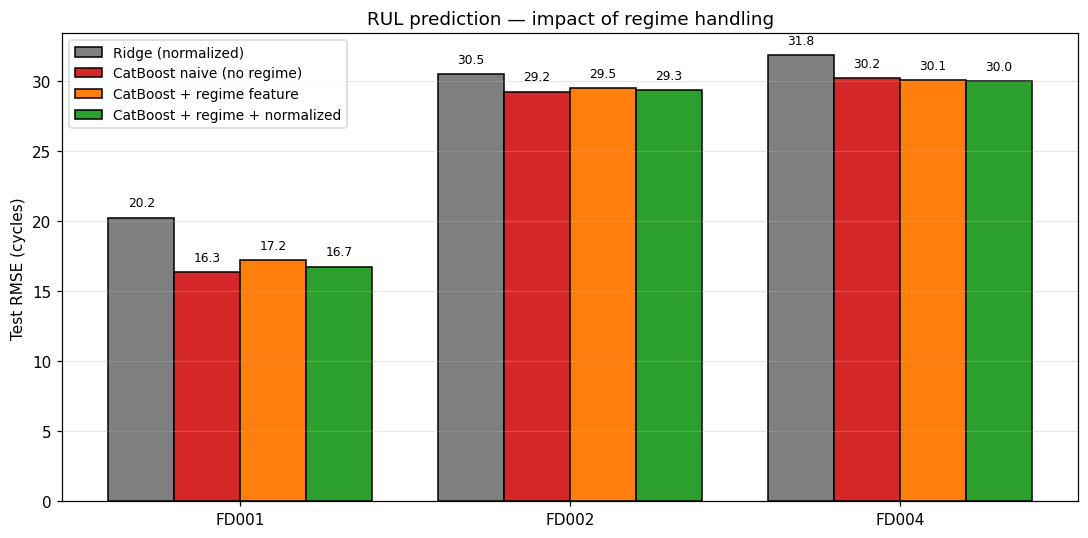

In [9]:
    # ==================== Plots ====================
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# 30. RMSE comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(configs))
w = 0.2
rmse_ridge = [ridge_results[ds]["RMSE"] for ds, _ in configs]
rmse_naive = [all_results[ds]["naive"]["metrics"]["RMSE"] for ds, _ in configs]
rmse_regime = [all_results[ds]["regime"]["metrics"]["RMSE"] for ds, _ in configs]
rmse_norm = [all_results[ds]["normalized"]["metrics"]["RMSE"] for ds, _ in configs]
ax.bar(x - 1.5*w, rmse_ridge, w, label="Ridge (normalized)", color="tab:gray", edgecolor="black")
ax.bar(x - 0.5*w, rmse_naive, w, label="CatBoost naive (no regime)", color="tab:red", edgecolor="black")
ax.bar(x + 0.5*w, rmse_regime, w, label="CatBoost + regime feature", color="tab:orange", edgecolor="black")
ax.bar(x + 1.5*w, rmse_norm, w, label="CatBoost + regime + normalized", color="tab:green", edgecolor="black")
for xi, a, b, c, d in zip(x, rmse_ridge, rmse_naive, rmse_regime, rmse_norm):
    for xp, v in [(xi - 1.5*w, a), (xi - 0.5*w, b), (xi + 0.5*w, c), (xi + 1.5*w, d)]:
        ax.text(xp, v + 0.8, f"{v:.1f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([ds for ds, _ in configs])
ax.set_ylabel("Test RMSE (cycles)")
ax.set_title("RUL prediction — impact of regime handling")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(IMG_DIR / "30_rmse_comparison.png", bbox_inches="tight")
plt.show()
plt.close()

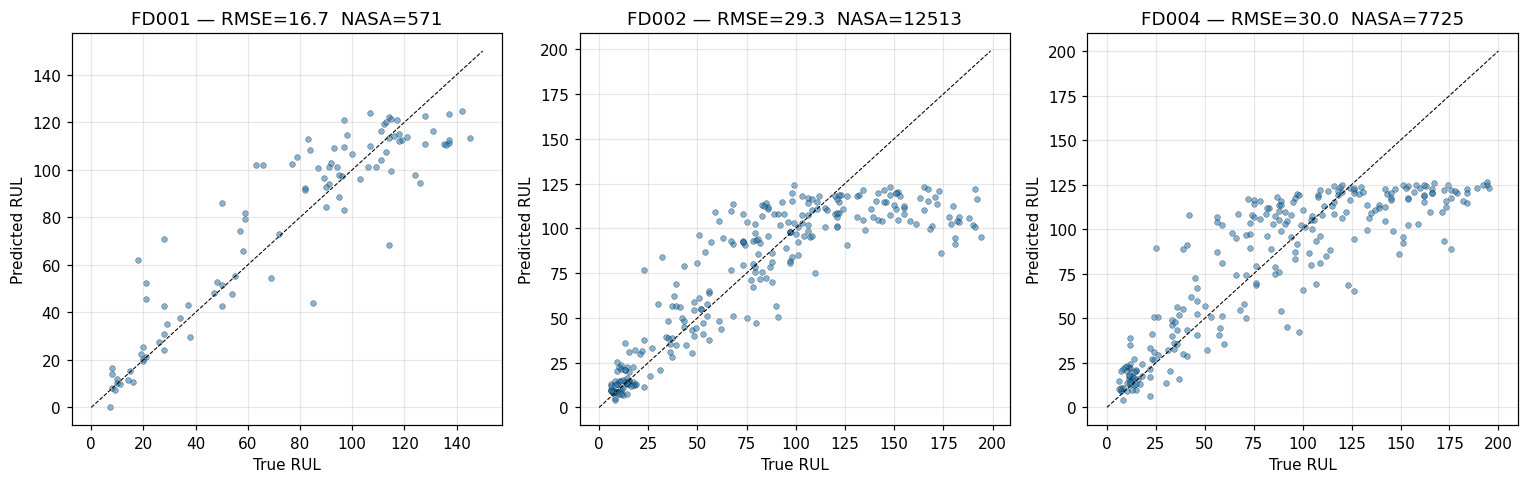

In [10]:
# 31. Scatter true vs predicted — 3 datasets, normalized model only
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (ds, _) in zip(axes, configs):
    r = all_results[ds]["normalized"]
    ax.scatter(r["y_true"], r["preds"], alpha=0.55, s=14, edgecolor="black", lw=0.3)
    lim = max(r["y_true"].max(), r["preds"].max()) + 5
    ax.plot([0, lim], [0, lim], "k--", lw=0.7)
    m = r["metrics"]
    ax.set_title(f"{ds} — RMSE={m['RMSE']:.1f}  NASA={m['NASA_score']:.0f}")
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Predicted RUL")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "31_scatter_3ds.png", bbox_inches="tight")
plt.show()
plt.close()

/tmp/ipykernel_67646/3970098564.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(errors, labels=labels, widths=0.5, showfliers=False,


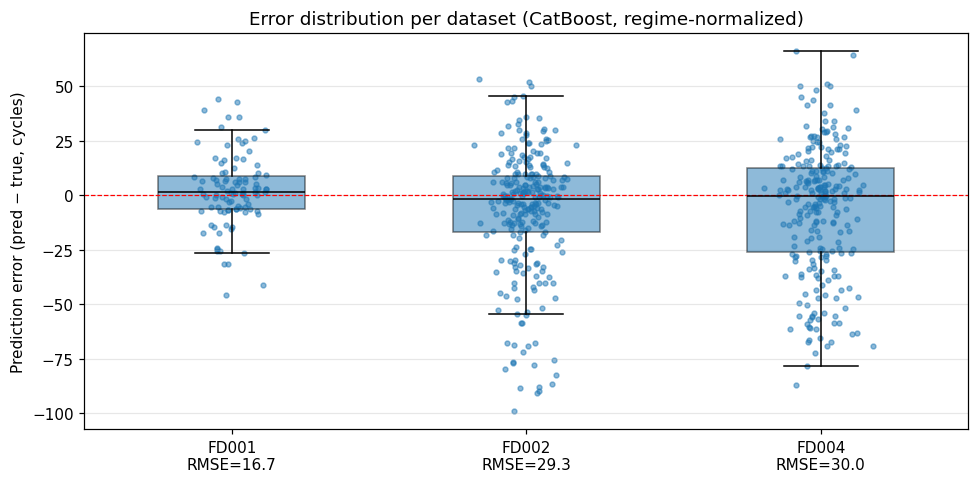

In [11]:
# 32. Error distribution per dataset (box + strip)
fig, ax = plt.subplots(figsize=(9, 4.5))
errors = []
labels = []
for ds, _ in configs:
    r = all_results[ds]["normalized"]
    err = r["preds"] - r["y_true"]
    errors.append(err)
    labels.append(f"{ds}\nRMSE={r['metrics']['RMSE']:.1f}")
bp = ax.boxplot(errors, labels=labels, widths=0.5, showfliers=False,
                patch_artist=True,
                boxprops=dict(facecolor="tab:blue", alpha=0.5),
                medianprops=dict(color="black"))
for i, e in enumerate(errors, 1):
    jitter = np.random.normal(i, 0.06, len(e))
    ax.scatter(jitter, e, alpha=0.5, s=10, color="tab:blue")
ax.axhline(0, color="red", ls="--", lw=0.8)
ax.set_ylabel("Prediction error (pred − true, cycles)")
ax.set_title("Error distribution per dataset (CatBoost, regime-normalized)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(IMG_DIR / "32_error_dist.png", bbox_inches="tight")
plt.show()
plt.close()

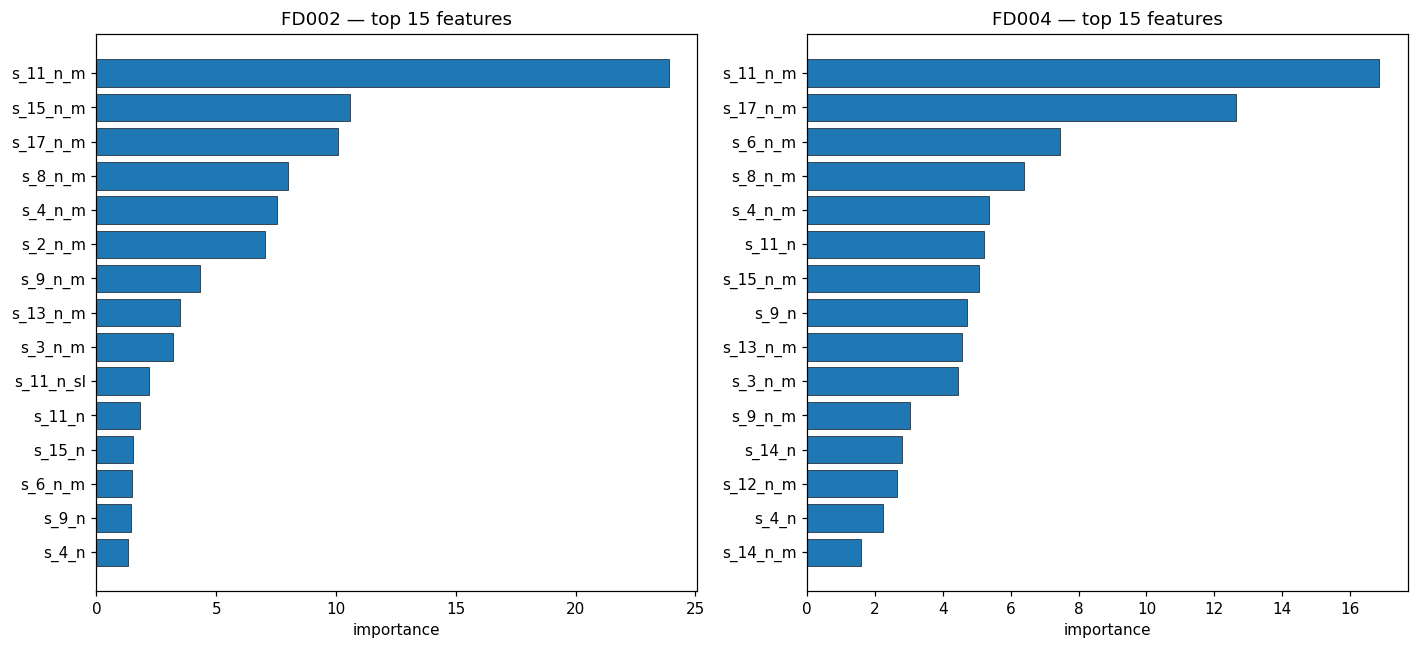

In [12]:
# 33. Feature importance comparison FD002 vs FD004
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, ds in zip(axes, ["FD002", "FD004"]):
    r = all_results[ds]["normalized"]
    imp = pd.Series(r["model"].get_feature_importance(), index=r["feature_cols"]).sort_values()
    top = imp.tail(15)
    ax.barh(top.index, top.values, color="tab:blue", edgecolor="black", lw=0.4)
    ax.set_title(f"{ds} — top 15 features")
    ax.set_xlabel("importance")
plt.tight_layout()
plt.savefig(IMG_DIR / "33_feature_imp.png", bbox_inches="tight")
plt.show()
plt.close()
